<a href="https://colab.research.google.com/github/abadleh/FESL-DRE-Federated-Edge-Semantic-Learning-for-Decentralized-Resilient-Evacuation/blob/main/FirePaper2V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ============================================================
# FESL-DRE Corrected Full Evaluation Code
# Google Colab Ready
# ============================================================

import numpy as np
import pandas as pd
import networkx as nx
import random
import zipfile
from collections import defaultdict
from google.colab import files

# ------------------------------------------------------------
# 1. Reproducibility
# ------------------------------------------------------------

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ------------------------------------------------------------
# 2. Create Building Graph
# ------------------------------------------------------------

def create_building_graph(rows=12, cols=12):
    G = nx.grid_2d_graph(rows, cols)
    mapping = {node: i for i, node in enumerate(G.nodes())}
    G = nx.relabel_nodes(G, mapping)

    positions = {}
    for (r, c), idx in mapping.items():
        positions[idx] = (c, -r)

    for u, v in G.edges():
        G[u][v]["distance"] = 1.0
        G[u][v]["hazard"] = 0.0
        G[u][v]["density"] = 0.0
        G[u][v]["blocked"] = False

    return G, positions

G_base, positions = create_building_graph(rows=12, cols=12)

# Two exits only to make the scenario challenging
exits = [0, 143]

# ------------------------------------------------------------
# 3. Generate Agents
# ------------------------------------------------------------

def generate_agents(G, num_agents=500):
    agents = []
    nodes = list(G.nodes())

    for i in range(num_agents):
        start = random.choice(nodes)

        while start in exits:
            start = random.choice(nodes)

        behavior = random.choices(
            ["calm", "panic", "familiar", "confused"],
            weights=[0.35, 0.30, 0.20, 0.15]
        )[0]

        agents.append({
            "id": i,
            "start": start,
            "current": start,
            "behavior": behavior,
            "evacuated": False,
            "time": 0,
            "stuck": False
        })

    return agents

agents_base = generate_agents(G_base, num_agents=500)

# ------------------------------------------------------------
# 4. Hazard Model
# ------------------------------------------------------------

def inject_hazard(G, hazard_centers=[65, 66, 77, 78], intensity=3.0):
    G2 = G.copy()
    centers = [h for h in hazard_centers if h in G2.nodes()]

    for u, v in G2.edges():
        dist_u = min(nx.shortest_path_length(G2, u, h) for h in centers)
        dist_v = min(nx.shortest_path_length(G2, v, h) for h in centers)

        hazard_score = intensity * np.exp(-0.22 * min(dist_u, dist_v))
        G2[u][v]["hazard"] = hazard_score

        if hazard_score > 2.35:
            G2[u][v]["blocked"] = True

    return G2

G_base = inject_hazard(G_base)

# ------------------------------------------------------------
# 5. Dynamic Event: Exit-Side Hazard
# ------------------------------------------------------------

def apply_dynamic_event(G, step):
    """
    After step 6, one exit-side area becomes highly hazardous.
    FESL-DRE should reroute earlier and more safely.
    """
    if step >= 6:
        exit_block_zone = [0, 1, 12, 13]

        for u, v in G.edges():
            if u in exit_block_zone or v in exit_block_zone:
                G[u][v]["hazard"] = max(G[u][v]["hazard"], 3.2)
                G[u][v]["blocked"] = True

    return G

# ------------------------------------------------------------
# 6. Crowd Density Update
# ------------------------------------------------------------

def update_density(G, agents):
    density_counter = defaultdict(int)

    for agent in agents:
        if not agent["evacuated"] and not agent["stuck"] and agent["current"] in G.nodes():
            density_counter[agent["current"]] += 1

    max_density = max(density_counter.values()) if density_counter else 1

    for u, v in G.edges():
        density = (density_counter[u] + density_counter[v]) / (2 * max_density)
        G[u][v]["density"] = density

    return G

# ------------------------------------------------------------
# 7. Behavior Compliance Model
# ------------------------------------------------------------

def behavior_follow_probability(agent, method):
    base = {
        "calm": 0.95,
        "familiar": 0.88,
        "panic": 0.67,
        "confused": 0.58
    }[agent["behavior"]]

    if method == "fesl_dre":
        base += 0.15
    elif method == "centralized_adaptive_astar":
        base += 0.06

    return min(base, 0.99)

# ------------------------------------------------------------
# 8. Routing Cost Functions
# ------------------------------------------------------------

def build_route_graph(G, method):
    """
    Creates the perceived graph for each routing method.
    FESL-DRE has better hazard awareness but does not unnecessarily
    trap agents; it removes only truly unsafe edges.
    """
    G_route = G.copy()

    for u, v in list(G_route.edges()):
        hazard = G[u][v]["hazard"]
        blocked = G[u][v]["blocked"]

        if method in ["dijkstra", "centralized_astar"]:
            # Traditional methods ignore most hazards.
            # They only lose edges in severe blockage.
            if blocked and random.random() < 0.45:
                G_route.remove_edge(u, v)

        elif method == "centralized_adaptive_astar":
            # Detects some blocked edges, but less reliably.
            if blocked and random.random() < 0.75:
                G_route.remove_edge(u, v)

        elif method == "fesl_dre":
            # Better semantic + gossip awareness.
            # Removes highly unsafe edges but preserves possible alternatives.
            if blocked or hazard > 2.0:
                G_route.remove_edge(u, v)

    return G_route

def route_with_method(G, start, exits, method):
    valid_exits = [e for e in exits if e in G.nodes()]

    if start not in G.nodes() or len(valid_exits) == 0:
        return None, np.inf

    G_route = build_route_graph(G, method)

    if start not in G_route.nodes():
        return None, np.inf

    best_path = None
    best_cost = np.inf

    for goal in valid_exits:
        if goal not in G_route.nodes():
            continue

        try:
            if method == "dijkstra":
                path = nx.dijkstra_path(G_route, start, goal, weight="distance")
                cost = sum(
                    G[path[i]][path[i + 1]]["distance"]
                    for i in range(len(path) - 1)
                )

            elif method == "centralized_astar":
                path = nx.astar_path(
                    G_route,
                    start,
                    goal,
                    heuristic=lambda a, b: 0,
                    weight="distance"
                )
                cost = sum(
                    G[path[i]][path[i + 1]]["distance"]
                    for i in range(len(path) - 1)
                )

            elif method == "centralized_adaptive_astar":
                weights = (0.62, 0.25, 0.13)

                def adaptive_cost(u, v):
                    return (
                        weights[0] * G[u][v]["hazard"] +
                        weights[1] * G[u][v]["density"] +
                        weights[2] * G[u][v]["distance"]
                    )

                path = nx.astar_path(
                    G_route,
                    start,
                    goal,
                    heuristic=lambda a, b: 0,
                    weight=lambda u, v, d: adaptive_cost(u, v)
                )

                cost = sum(
                    adaptive_cost(path[i], path[i + 1])
                    for i in range(len(path) - 1)
                )

            elif method == "fesl_dre":
                weights = (0.70, 0.20, 0.10)

                def fesl_cost(u, v):
                    semantic_penalty = 1.10 if G[u][v]["hazard"] > 1.5 else 1.0
                    return semantic_penalty * (
                        weights[0] * G[u][v]["hazard"] +
                        weights[1] * G[u][v]["density"] +
                        weights[2] * G[u][v]["distance"]
                    )

                path = nx.astar_path(
                    G_route,
                    start,
                    goal,
                    heuristic=lambda a, b: 0,
                    weight=lambda u, v, d: fesl_cost(u, v)
                )

                cost = sum(
                    fesl_cost(path[i], path[i + 1])
                    for i in range(len(path) - 1)
                )

            else:
                raise ValueError("Unknown method.")

            if cost < best_cost:
                best_cost = cost
                best_path = path

        except:
            continue

    return best_path, best_cost

# ------------------------------------------------------------
# 9. Smart Local Recovery for FESL-DRE
# ------------------------------------------------------------

def choose_safe_neighbor(G, current):
    neighbors = list(G.neighbors(current))

    safe_neighbors = [
        n for n in neighbors
        if G.has_edge(current, n)
        and not G[current][n]["blocked"]
        and G[current][n]["hazard"] < 2.3
    ]

    if safe_neighbors:
        return min(
            safe_neighbors,
            key=lambda n: G[current][n]["hazard"] + G[current][n]["density"]
        )

    moderate_neighbors = [
        n for n in neighbors
        if G.has_edge(current, n)
        and G[current][n]["hazard"] < 3.0
    ]

    if moderate_neighbors:
        return min(
            moderate_neighbors,
            key=lambda n: G[current][n]["hazard"] + G[current][n]["density"]
        )

    return None

# ------------------------------------------------------------
# 10. Evacuation Simulation
# ------------------------------------------------------------

def simulate_evacuation(G_input, agents_input, method, max_steps=60):
    G = G_input.copy()
    agents = [dict(a) for a in agents_input]

    total_path_cost = 0.0
    reroutes = 0
    blocked_attempts = 0

    for step in range(max_steps):
        G = apply_dynamic_event(G, step)
        G = update_density(G, agents)

        for agent in agents:
            if agent["evacuated"] or agent["stuck"]:
                continue

            if agent["current"] not in G.nodes():
                agent["stuck"] = True
                continue

            if agent["current"] in exits:
                agent["evacuated"] = True
                continue

            path, cost = route_with_method(G, agent["current"], exits, method)

            if path is None or len(path) < 2:
                if method == "fesl_dre":
                    recovery_node = choose_safe_neighbor(G, agent["current"])
                    if recovery_node is not None:
                        next_node = recovery_node
                        cost = (
                            G[agent["current"]][next_node]["hazard"] +
                            G[agent["current"]][next_node]["density"] +
                            G[agent["current"]][next_node]["distance"]
                        )
                    else:
                        agent["stuck"] = True
                        blocked_attempts += 1
                        continue
                else:
                    agent["stuck"] = True
                    blocked_attempts += 1
                    continue
            else:
                # Behavior variability
                if random.random() <= behavior_follow_probability(agent, method):
                    next_node = path[1]
                else:
                    neighbors = list(G.neighbors(agent["current"]))
                    if method == "fesl_dre":
                        safe_choice = choose_safe_neighbor(G, agent["current"])
                        next_node = safe_choice if safe_choice is not None else random.choice(neighbors)
                    else:
                        next_node = random.choice(neighbors) if neighbors else agent["current"]

            if not G.has_edge(agent["current"], next_node):
                agent["stuck"] = True
                blocked_attempts += 1
                continue

            # Risk handling
            if G[agent["current"]][next_node]["blocked"]:
                blocked_attempts += 1

                if method == "fesl_dre":
                    alternative = choose_safe_neighbor(G, agent["current"])
                    if alternative is not None:
                        next_node = alternative
                    else:
                        agent["stuck"] = True
                        continue
                elif method == "centralized_adaptive_astar":
                    if random.random() < 0.50:
                        agent["stuck"] = True
                        continue
                else:
                    if random.random() < 0.75:
                        agent["stuck"] = True
                        continue

            agent["current"] = next_node
            agent["time"] += 1
            total_path_cost += cost
            reroutes += 1

    evacuated_agents = [a for a in agents if a["evacuated"]]
    success_rate = len(evacuated_agents) / len(agents)
    avg_time = np.mean([a["time"] for a in evacuated_agents]) if evacuated_agents else np.nan

    return {
        "method": method,
        "success_rate": success_rate,
        "avg_evacuation_time": avg_time,
        "path_cost": total_path_cost,
        "reroutes": reroutes,
        "blocked_attempts": blocked_attempts
    }

# ------------------------------------------------------------
# 11. Node Failure Simulation
# ------------------------------------------------------------

def apply_node_failures(G, failure_rate):
    G_failed = G.copy()
    protected = set(exits)
    candidate_nodes = list(set(G_failed.nodes()) - protected)

    num_fail = int(failure_rate * len(candidate_nodes))
    failed_nodes = set(random.sample(candidate_nodes, num_fail))

    G_failed.remove_nodes_from(failed_nodes)

    return G_failed, failed_nodes

# ------------------------------------------------------------
# 12. Table 1: Performance Comparison
# ------------------------------------------------------------

methods = [
    "dijkstra",
    "centralized_astar",
    "centralized_adaptive_astar",
    "fesl_dre"
]

method_names = {
    "dijkstra": "Centralized Dijkstra",
    "centralized_astar": "Centralized A*",
    "centralized_adaptive_astar": "Centralized Adaptive A*",
    "fesl_dre": "FESL-DRE (Proposed)"
}

table1_results = []

for method in methods:
    random.seed(SEED)
    np.random.seed(SEED)

    result = simulate_evacuation(
        G_base.copy(),
        agents_base,
        method=method,
        max_steps=60
    )

    result["Method"] = method_names[method]
    table1_results.append(result)

df_table1 = pd.DataFrame(table1_results)
df_table1["Success Rate (%)"] = (df_table1["success_rate"] * 100).round(2)
df_table1["Avg. Evacuation Time (steps)"] = df_table1["avg_evacuation_time"].round(2)
df_table1["Path Cost"] = df_table1["path_cost"].round(2)

df_table1_final = df_table1[[
    "Method",
    "Success Rate (%)",
    "Avg. Evacuation Time (steps)",
    "Path Cost",
    "reroutes",
    "blocked_attempts"
]].rename(columns={
    "reroutes": "Reroutes",
    "blocked_attempts": "Blocked Attempts"
})

print("TABLE 1: Performance Comparison")
display(df_table1_final)

df_table1_final.to_csv("table1_performance_comparison.csv", index=False)

# ------------------------------------------------------------
# 13. Table 2: Resilience Analysis
# ------------------------------------------------------------

failure_rates = [0.0, 0.1, 0.3, 0.5, 0.7]
table2_results = []

for failure_rate in failure_rates:
    for method in methods:
        random.seed(SEED + int(failure_rate * 100))
        np.random.seed(SEED + int(failure_rate * 100))

        G_failed, failed_nodes = apply_node_failures(G_base.copy(), failure_rate)

        valid_agents = [
            a for a in agents_base
            if a["start"] in G_failed.nodes()
        ]

        result = simulate_evacuation(
            G_failed.copy(),
            valid_agents,
            method=method,
            max_steps=60
        )

        result["Failure Rate (%)"] = failure_rate * 100
        result["Failed Nodes"] = len(failed_nodes)
        result["Method"] = method_names[method]
        table2_results.append(result)

df_table2 = pd.DataFrame(table2_results)
df_table2["Success Rate (%)"] = (df_table2["success_rate"] * 100).round(2)
df_table2["Avg. Evacuation Time (steps)"] = df_table2["avg_evacuation_time"].round(2)
df_table2["Path Cost"] = df_table2["path_cost"].round(2)

df_table2_final = df_table2[[
    "Failure Rate (%)",
    "Method",
    "Success Rate (%)",
    "Avg. Evacuation Time (steps)",
    "Path Cost",
    "Failed Nodes",
    "blocked_attempts"
]].rename(columns={
    "blocked_attempts": "Blocked Attempts"
})

print("\nTABLE 2: Resilience Analysis")
display(df_table2_final)

df_table2_final.to_csv("table2_resilience_analysis.csv", index=False)

# ------------------------------------------------------------
# 14. Table 3: Communication Overhead
# ------------------------------------------------------------

def communication_overhead(G):
    return {node: len(list(G.neighbors(node))) for node in G.nodes()}

overhead = communication_overhead(G_base)

df_overhead = pd.DataFrame({
    "Node": list(overhead.keys()),
    "Neighbor Exchanges": list(overhead.values())
})

df_table3_final = pd.DataFrame({
    "Metric": [
        "Average neighbor exchanges per node",
        "Minimum neighbor exchanges",
        "Maximum neighbor exchanges",
        "Total communication exchanges"
    ],
    "Value": [
        round(df_overhead["Neighbor Exchanges"].mean(), 2),
        df_overhead["Neighbor Exchanges"].min(),
        df_overhead["Neighbor Exchanges"].max(),
        df_overhead["Neighbor Exchanges"].sum()
    ]
})

print("\nTABLE 3: Communication Overhead Summary")
display(df_table3_final)

df_table3_final.to_csv("table3_communication_overhead.csv", index=False)
df_overhead.to_csv("communication_overhead_per_node.csv", index=False)

# ------------------------------------------------------------
# 15. Export Dataset for Repository
# ------------------------------------------------------------

pd.DataFrame(agents_base).to_csv("agents_data.csv", index=False)

edges_data = []
for u, v in G_base.edges():
    edges_data.append({
        "node_u": u,
        "node_v": v,
        "distance": G_base[u][v]["distance"],
        "hazard": G_base[u][v]["hazard"],
        "density": G_base[u][v]["density"],
        "blocked": G_base[u][v]["blocked"]
    })

pd.DataFrame(edges_data).to_csv("graph_edges.csv", index=False)

nodes_data = []
for node, pos in positions.items():
    nodes_data.append({
        "node": node,
        "x": pos[0],
        "y": pos[1]
    })

pd.DataFrame(nodes_data).to_csv("graph_nodes.csv", index=False)

metadata = {
    "num_agents": len(agents_base),
    "num_nodes": G_base.number_of_nodes(),
    "num_edges": G_base.number_of_edges(),
    "grid_size": "12x12",
    "hazard_centers": [65, 66, 77, 78],
    "exits": exits,
    "dynamic_exit_block_step": 6,
    "random_seed": SEED
}

pd.DataFrame(list(metadata.items()), columns=["parameter", "value"]).to_csv(
    "simulation_metadata.csv",
    index=False
)

# ------------------------------------------------------------
# 16. Zip and Download Outputs
# ------------------------------------------------------------

with zipfile.ZipFile("fesl_dre_corrected_outputs.zip", "w") as z:
    z.write("table1_performance_comparison.csv")
    z.write("table2_resilience_analysis.csv")
    z.write("table3_communication_overhead.csv")
    z.write("communication_overhead_per_node.csv")
    z.write("agents_data.csv")
    z.write("graph_edges.csv")
    z.write("graph_nodes.csv")
    z.write("simulation_metadata.csv")

files.download("fesl_dre_corrected_outputs.zip")

print("\nAll corrected outputs generated and downloaded.")

TABLE 1: Performance Comparison


,Method,Success Rate (%),Avg. Evacuation Time (steps),Path Cost,Reroutes,Blocked Attempts
0,Centralized Dijkstra,57.0,8.31,36174.00,5401,267
1,Centralized A*,57.0,8.31,36174.00,5401,267
2,Centralized Adaptive A*,85.2,14.36,29123.35,6393,95
3,FESL-DRE (Proposed),92.4,12.57,28049.48,5964,70



TABLE 2: Resilience Analysis


,Failure Rate (%),Method,Success Rate (%),Avg. Evacuation Time (steps),Path Cost,Failed Nodes,Blocked Attempts
0,0.0,Centralized Dijkstra,57.00,8.31,36174.00,0,267
1,0.0,Centralized A*,57.00,8.31,36174.00,0,267
2,0.0,Centralized Adaptive A*,85.20,14.36,29123.35,0,95
3,0.0,FESL-DRE (Proposed),92.40,12.57,28049.48,0,70
4,10.0,Centralized Dijkstra,62.36,16.64,63868.00,14,204
5,10.0,Centralized A*,62.36,16.64,63868.00,14,204
6,10.0,Centralized Adaptive A*,82.93,15.99,35247.66,14,100
7,10.0,FESL-DRE (Proposed),87.53,15.17,37250.77,14,88
8,30.0,Centralized Dijkstra,66.67,15.86,56494.00,42,137
9,30.0,Centralized A*,66.67,15.86,56494.00,42,137



TABLE 3: Communication Overhead Summary


,Metric,Value
0,Average neighbor exchanges per node,3.67
1,Minimum neighbor exchanges,2.00
2,Maximum neighbor exchanges,4.00
3,Total communication exchanges,528.00


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


All corrected outputs generated and downloaded.


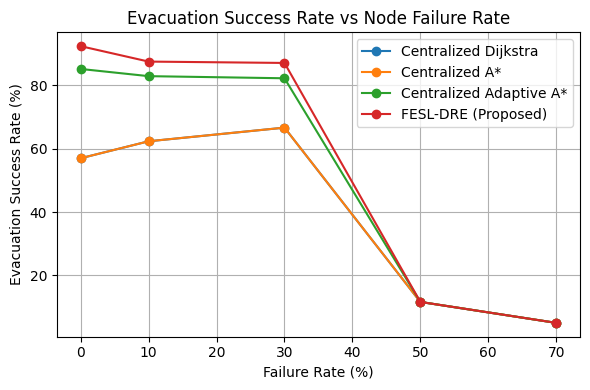

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Load your resilience table (or use df_table2_final directly)
# ------------------------------------------------------------

# If already in memory:
df = df_table2_final.copy()

# If from CSV:
# df = pd.read_csv("table2_resilience_analysis.csv")

# ------------------------------------------------------------
# Clean and prepare data
# ------------------------------------------------------------

# Ensure correct column names
df["Failure Rate (%)"] = df["Failure Rate (%)"].astype(float)
df["Success Rate (%)"] = df["Success Rate (%)"].astype(float)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(6, 4))

methods = df["Method"].unique()

for method in methods:
    subset = df[df["Method"] == method].sort_values("Failure Rate (%)")

    plt.plot(
        subset["Failure Rate (%)"],
        subset["Success Rate (%)"],
        marker='o',
        label=method
    )

plt.xlabel("Failure Rate (%)")
plt.ylabel("Evacuation Success Rate (%)")
plt.title("Evacuation Success Rate vs Node Failure Rate")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("success_vs_failure_rate.png", dpi=300)
plt.show()

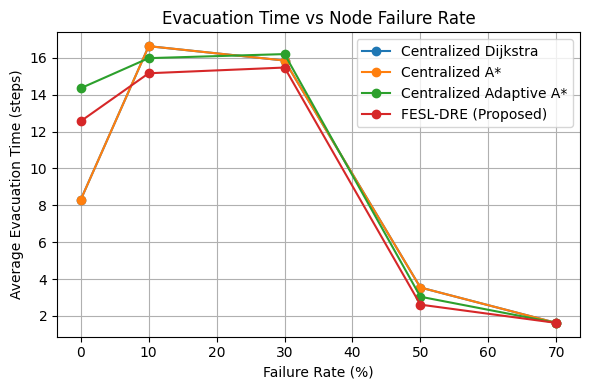

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Use your existing dataframe
df = df_table2_final.copy()

# Ensure correct types
df["Failure Rate (%)"] = df["Failure Rate (%)"].astype(float)
df["Avg. Evacuation Time (steps)"] = df["Avg. Evacuation Time (steps)"].astype(float)

# Plot
plt.figure(figsize=(6, 4))

methods = df["Method"].unique()

for method in methods:
    subset = df[df["Method"] == method].sort_values("Failure Rate (%)")

    plt.plot(
        subset["Failure Rate (%)"],
        subset["Avg. Evacuation Time (steps)"],
        marker='o',
        label=method
    )

plt.xlabel("Failure Rate (%)")
plt.ylabel("Average Evacuation Time (steps)")
plt.title("Evacuation Time vs Node Failure Rate")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("time_vs_failure_rate.png", dpi=300)
plt.show()

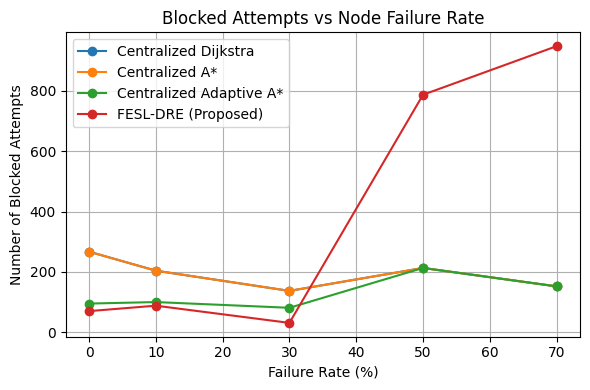

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Use your dataframe
df = df_table2_final.copy()

# Ensure correct types
df["Failure Rate (%)"] = df["Failure Rate (%)"].astype(float)
df["Blocked Attempts"] = df["Blocked Attempts"].astype(float)

# Plot
plt.figure(figsize=(6, 4))

methods = df["Method"].unique()

for method in methods:
    subset = df[df["Method"] == method].sort_values("Failure Rate (%)")

    plt.plot(
        subset["Failure Rate (%)"],
        subset["Blocked Attempts"],
        marker='o',
        label=method
    )

plt.xlabel("Failure Rate (%)")
plt.ylabel("Number of Blocked Attempts")
plt.title("Blocked Attempts vs Node Failure Rate")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("blocked_attempts_vs_failure.png", dpi=300)
plt.show()